In [ ]:
import pandas as pd
import numpy as np

In [12]:
from google.colab import files
uploaded = files.upload()  # re-upload archive.zip fresh

import zipfile
with zipfile.ZipFile('archive.zip', 'r') as z:
    z.extractall('.')

df = pd.read_csv('creditcard.csv')

# Sanity checks BEFORE doing anything else
assert df.shape == (284807, 31), f"Unexpected shape: {df.shape} — file may still be corrupted/truncated"
assert df.isnull().sum().sum() == 0, "NaNs present — file may still be corrupted/truncated"
print("✅ File verified:", df.shape, "| NaNs:", df.isnull().sum().sum())

Saving archive.zip to archive.zip
✅ File verified: (284807, 31) | NaNs: 0


In [14]:
# STEP 1: DATA OVERVIEW
import pandas as pd
import numpy as np

df = pd.read_csv('creditcard.csv')

# Basic structure
print("Shape (rows, cols):", df.shape)
print("\nColumn names:\n", df.columns.tolist())

print("\n--- Data types & non-null counts ---")
df.info()

print("\n--- First 5 rows ---")
display(df.head())

print("\n--- Last 5 rows ---")
display(df.tail())

# --- Missing values ---
print("\n--- Missing values per column ---")
print(df.isnull().sum())

# --- Duplicate rows ---
print("\nDuplicate rows:", df.duplicated().sum())

# --- Summary statistics ---
print("\n--- Descriptive statistics (all columns) ---")
display(df.describe().T)

# --- Target variable balance (Class: 0 = normal, 1 = fraud) ---
print("\n--- Class distribution ---")
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Shape (rows, cols): (284807, 31)

Column names:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

--- Data types & non-null counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     2848

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--- Last 5 rows ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0



--- Missing values per column ---
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicate rows: 1081

--- Descriptive statistics (all columns) ---


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995



--- Class distribution ---
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


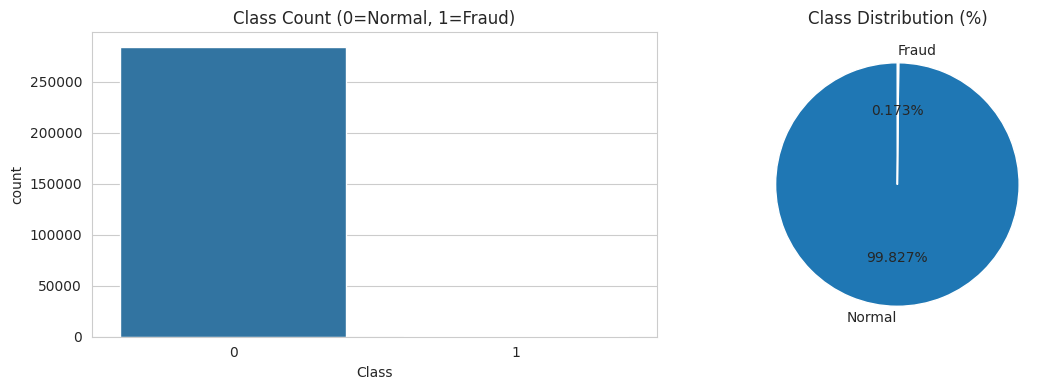

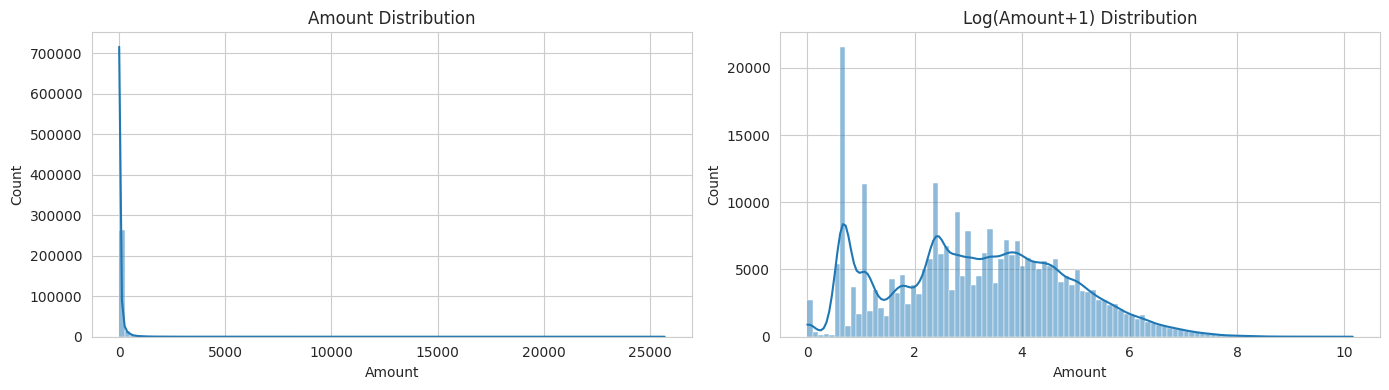

Amount stats:
 count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


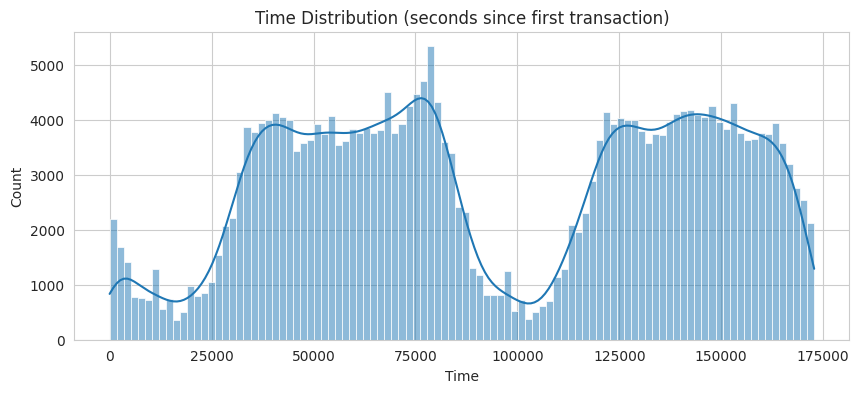

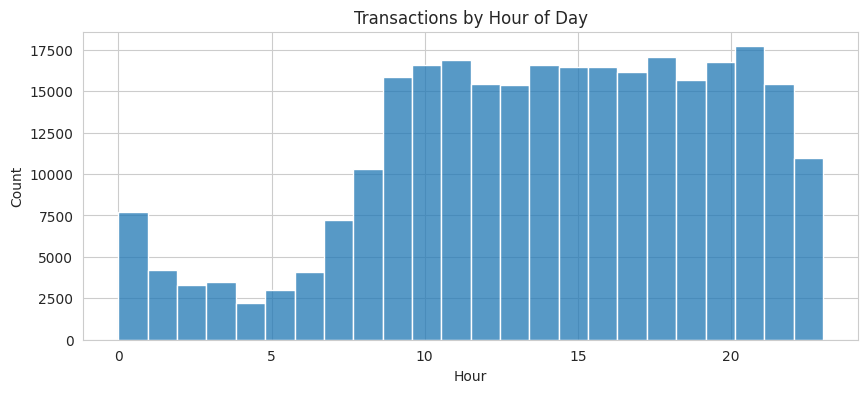

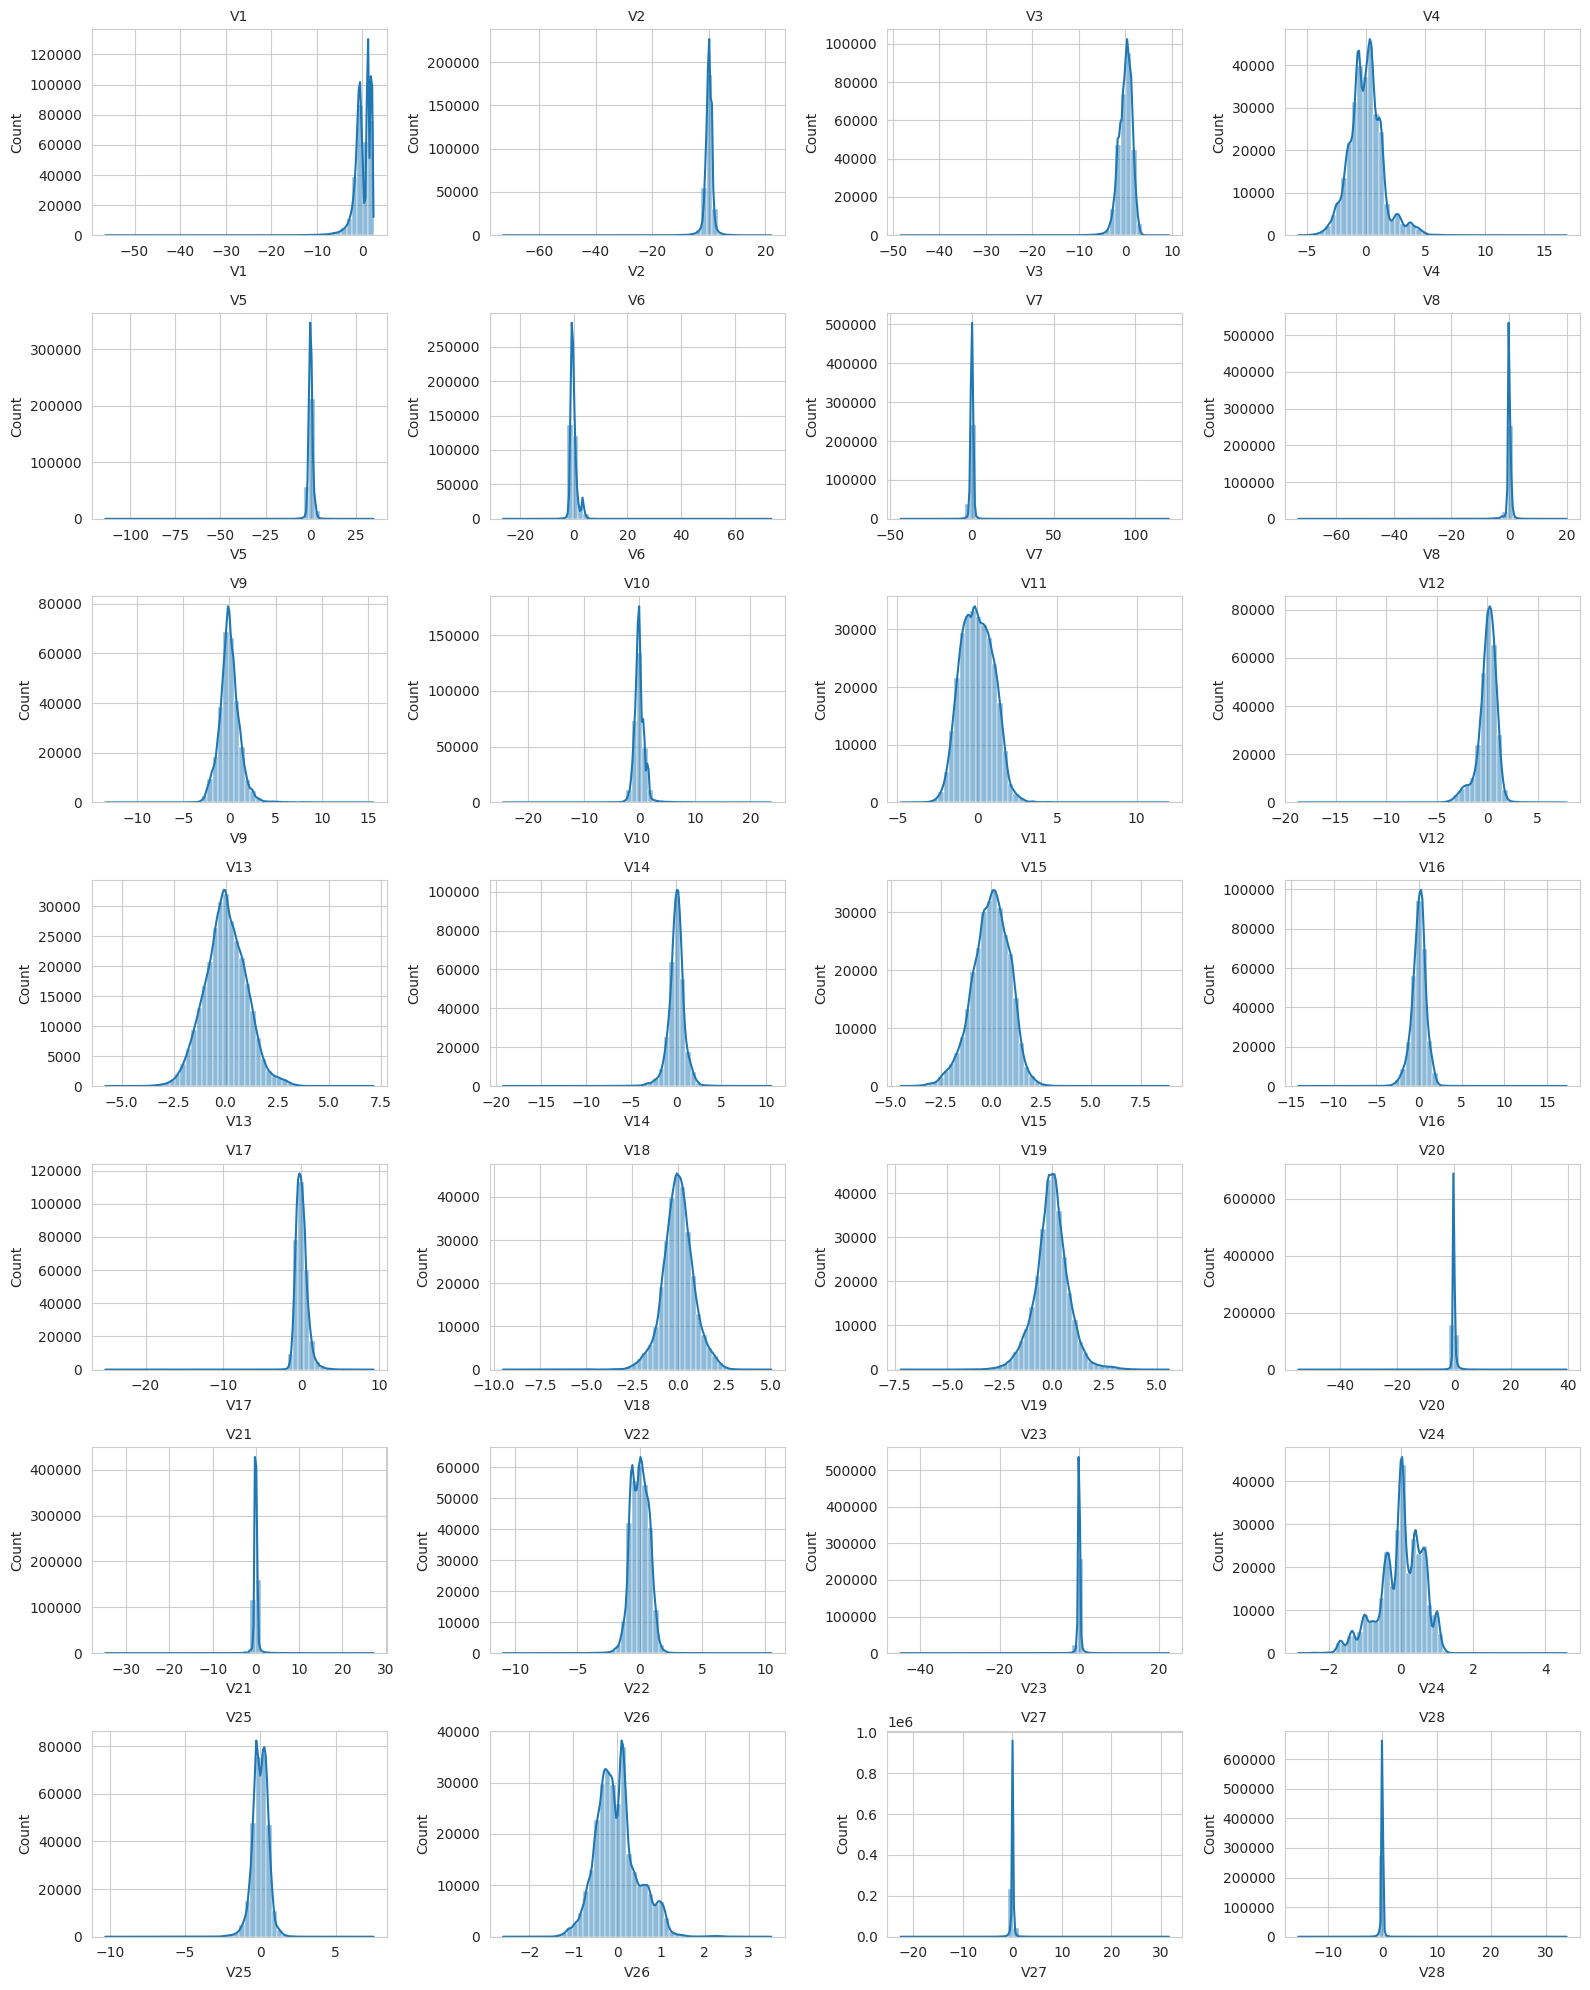


--- Skewness & Kurtosis ---


,skewness,kurtosis
Amount,16.977724,845.092646
V28,11.192091,933.397502
V21,3.592991,207.287040
V7,2.553907,405.607417
V6,1.826581,42.642494
V10,1.187141,31.988239
V4,0.676292,2.635455
V26,0.576693,0.919006
V9,0.554680,3.731311
V11,0.356506,1.633921


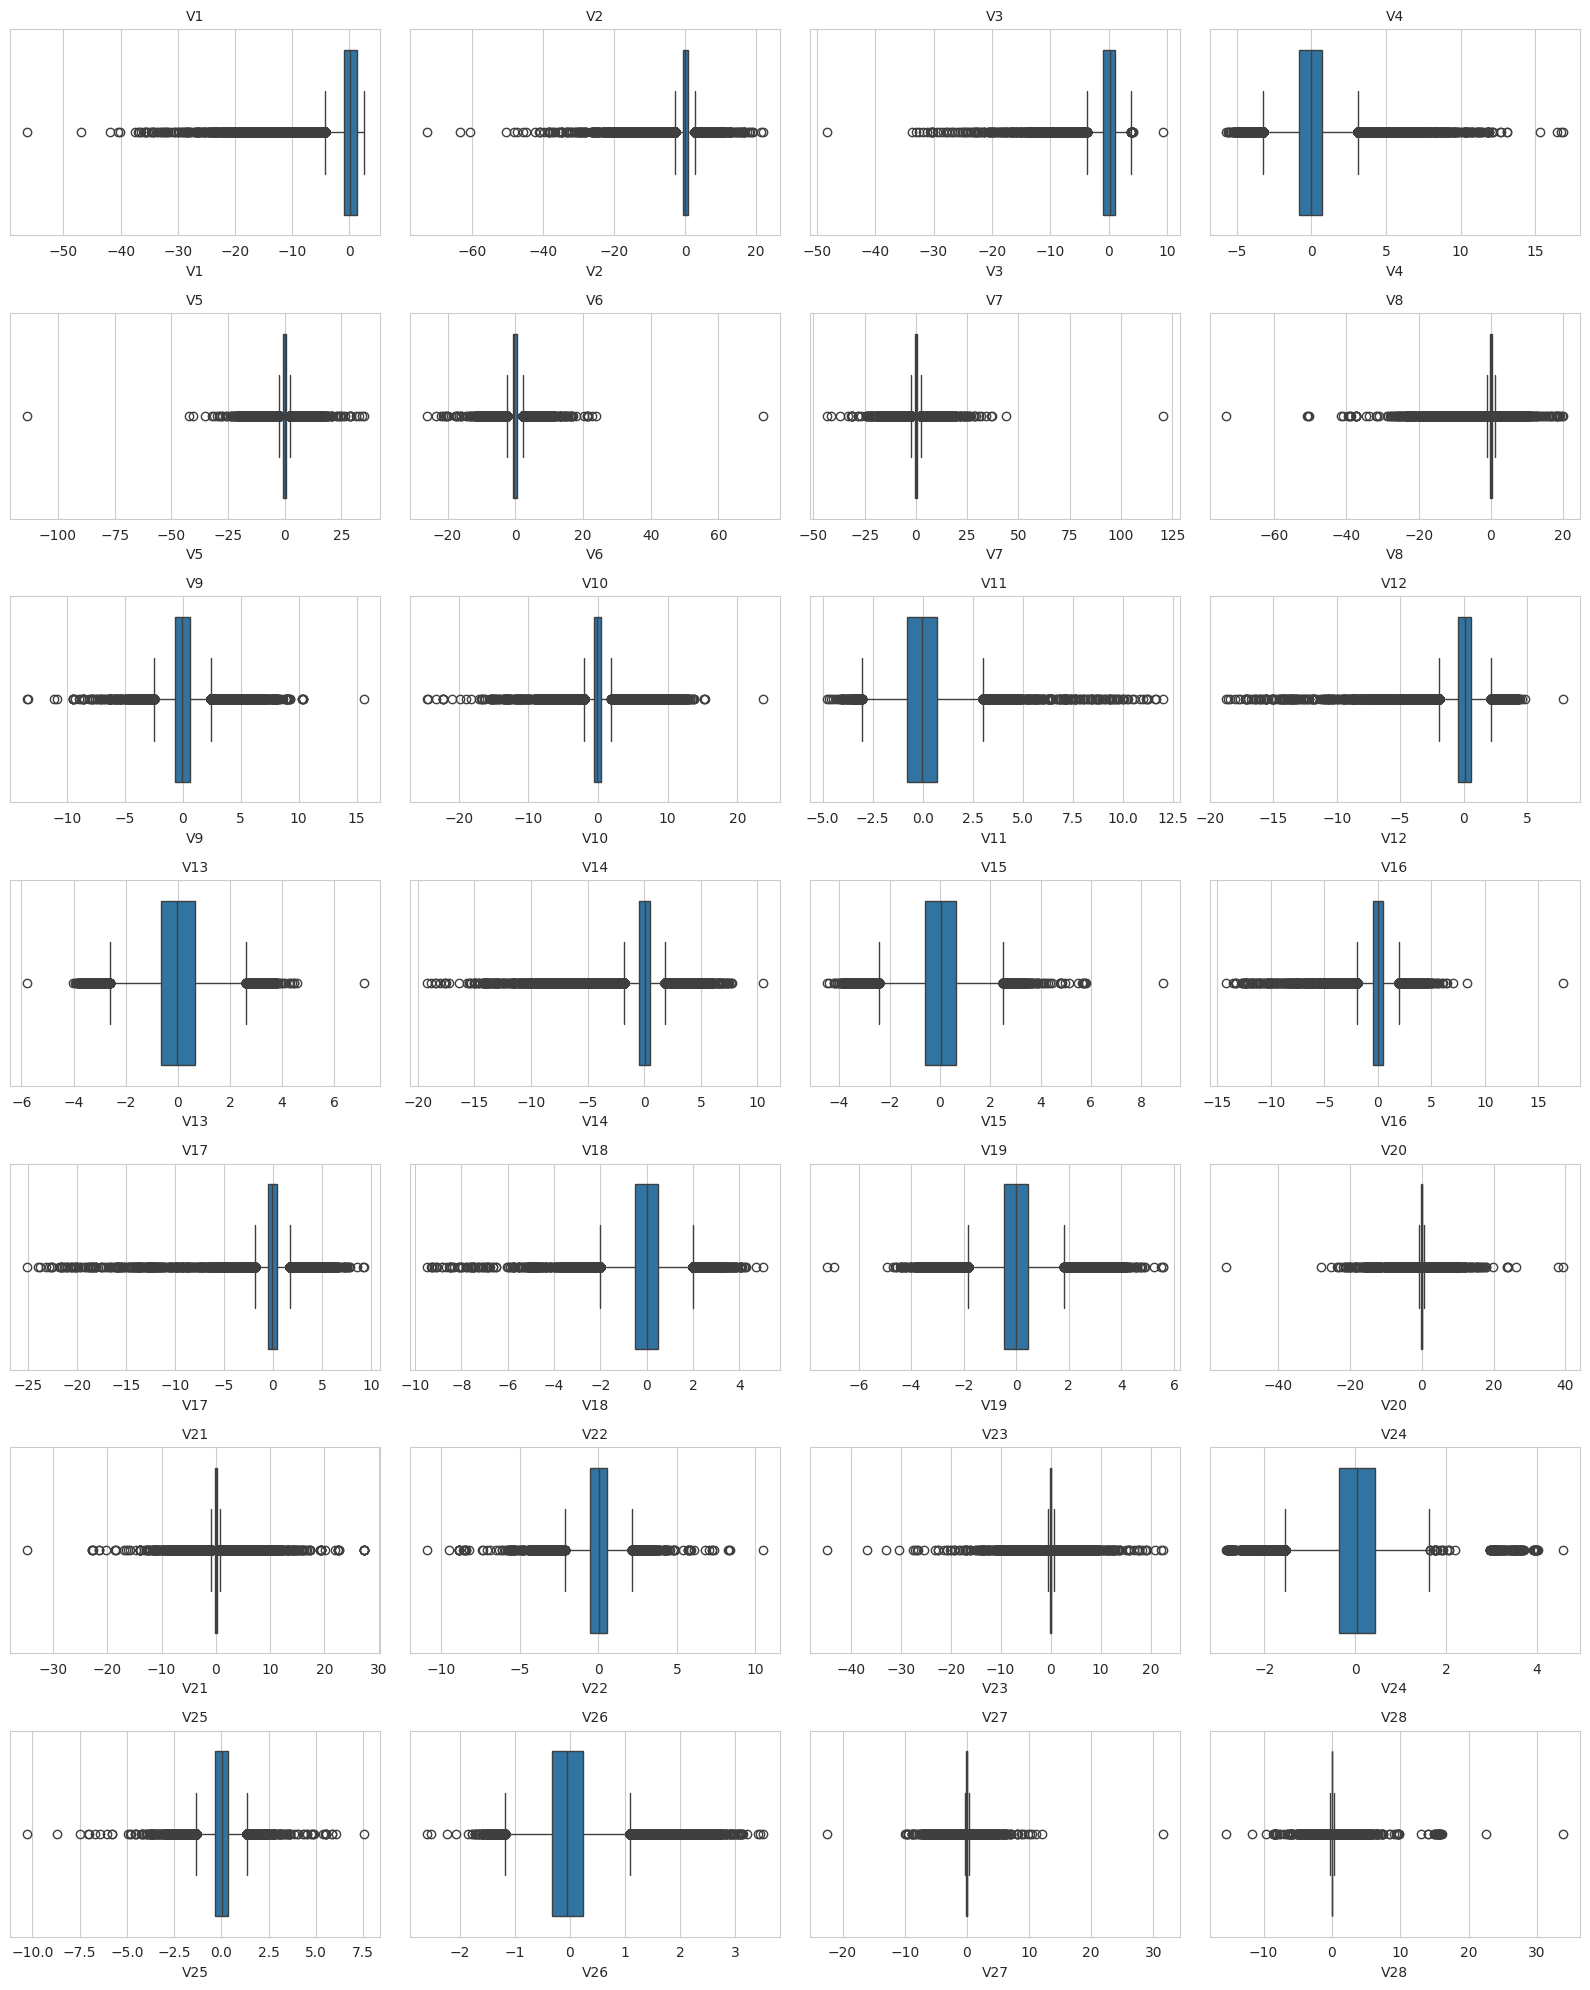

In [15]:
# Univariate analysis

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Class', data=df, ax=ax[0])
ax[0].set_title('Class Count (0=Normal, 1=Fraud)')

class_pct = df['Class'].value_counts(normalize=True) * 100
ax[1].pie(class_pct, labels=['Normal', 'Fraud'], autopct='%1.3f%%', startangle=90)
ax[1].set_title('Class Distribution (%)')
plt.tight_layout()
plt.show()

# --- 2.2 Amount distribution ---
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['Amount'], bins=100, ax=ax[0], kde=True)
ax[0].set_title('Amount Distribution')

sns.histplot(np.log1p(df['Amount']), bins=100, ax=ax[1], kde=True)
ax[1].set_title('Log(Amount+1) Distribution')  # helps with the heavy right skew
plt.tight_layout()
plt.show()

print("Amount stats:\n", df['Amount'].describe())

# --- 2.3 Time distribution ---
plt.figure(figsize=(10, 4))
sns.histplot(df['Time'], bins=100, kde=True)
plt.title('Time Distribution (seconds since first transaction)')
plt.show()

# Convert Time to hour-of-day (dataset spans ~2 days)
df['Hour'] = (df['Time'] // 3600) % 24
plt.figure(figsize=(10, 4))
sns.histplot(df['Hour'], bins=24)
plt.title('Transactions by Hour of Day')
plt.show()

# --- 2.4 V1-V28 distributions (grid of histograms) ---
v_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(16, 20))
axes = axes.flatten()
for i, col in enumerate(v_features):
    sns.histplot(df[col], bins=50, ax=axes[i], kde=True)
    axes[i].set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

# --- 2.5 Skewness & kurtosis summary for all numeric features ---
skew_kurt = pd.DataFrame({
    'skewness': df[v_features + ['Amount', 'Time']].skew(),
    'kurtosis': df[v_features + ['Amount', 'Time']].kurtosis()
}).sort_values('skewness', ascending=False)

print("\n--- Skewness & Kurtosis ---")
display(skew_kurt)

# --- 2.6 Outlier check via boxplots (V1-V28) ---
fig, axes = plt.subplots(7, 4, figsize=(16, 20))
axes = axes.flatten()
for i, col in enumerate(v_features):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

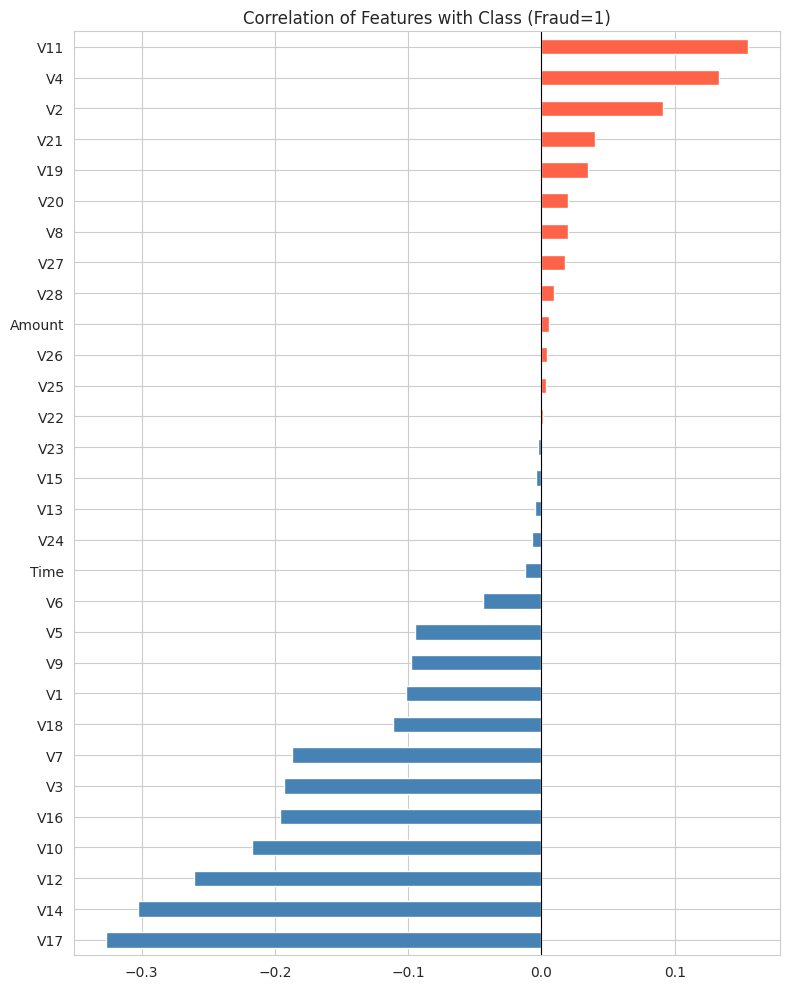

--- Top positively correlated with fraud ---
V11    0.154876
V4     0.133447
V2     0.091289
V21    0.040413
V19    0.034783
Name: Class, dtype: float64

--- Top negatively correlated with fraud ---
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


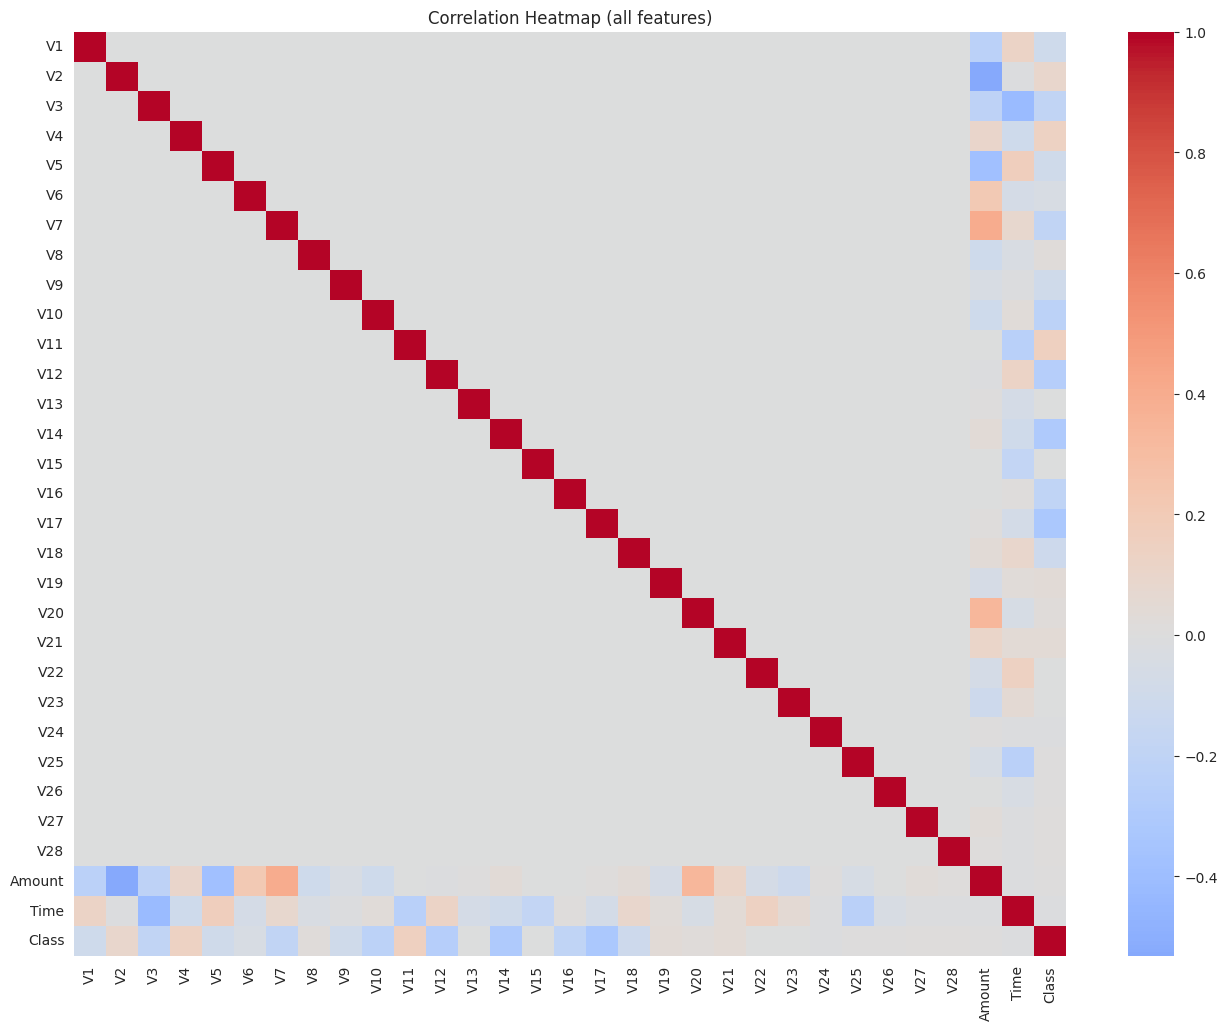

In [16]:
# STEP 3: BIVARIATE ANALYSIS

v_features = [f'V{i}' for i in range(1, 29)]

# --- 3.1 Correlation of each feature with Class ---
corr_with_class = df[v_features + ['Amount', 'Time', 'Class']].corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(8, 10))
corr_with_class.plot(kind='barh', color=(corr_with_class > 0).map({True: 'tomato', False: 'steelblue'}))
plt.title('Correlation of Features with Class (Fraud=1)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("--- Top positively correlated with fraud ---")
print(corr_with_class.sort_values(ascending=False).head(5))
print("\n--- Top negatively correlated with fraud ---")
print(corr_with_class.sort_values().head(5))

# --- 3.2 Full correlation heatmap ---
plt.figure(figsize=(16, 12))
sns.heatmap(df[v_features + ['Amount', 'Time', 'Class']].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap (all features)')
plt.show()

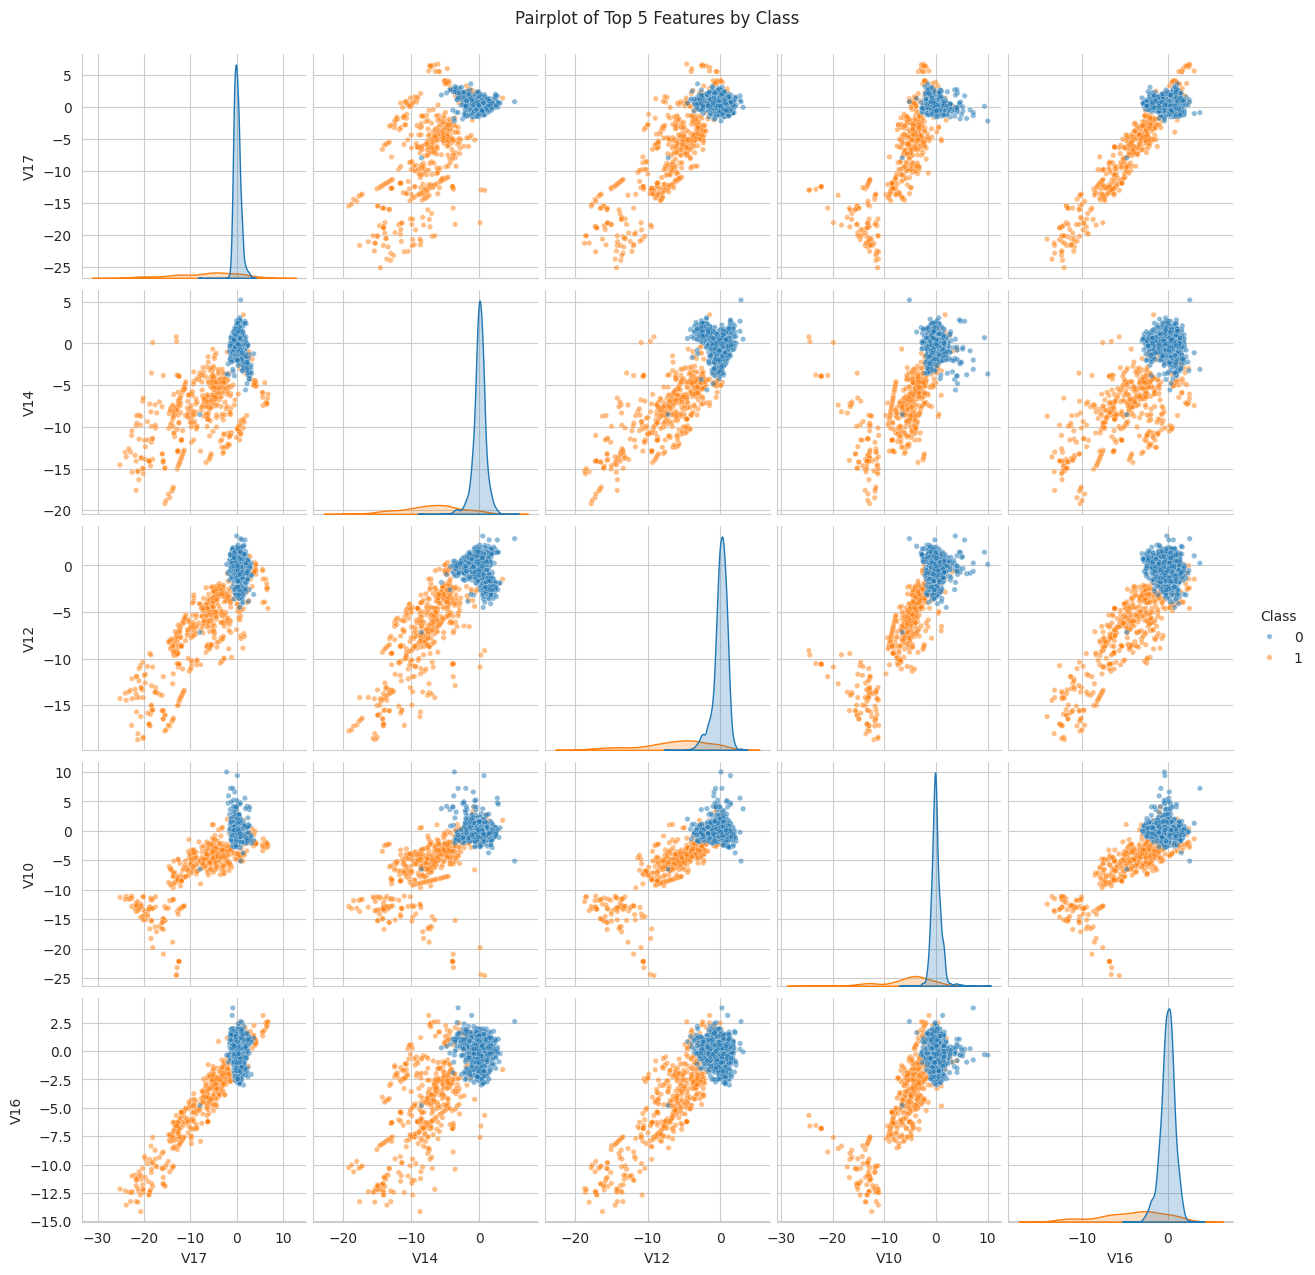

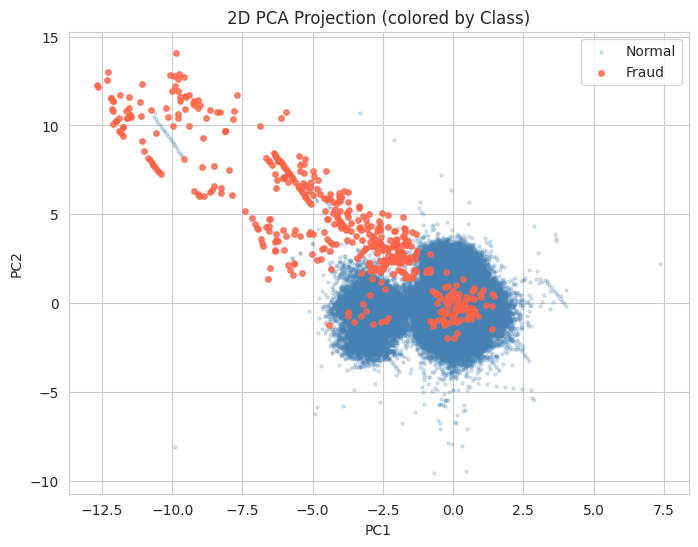

Explained variance ratio (PC1, PC2): [0.03571429 0.03571429]


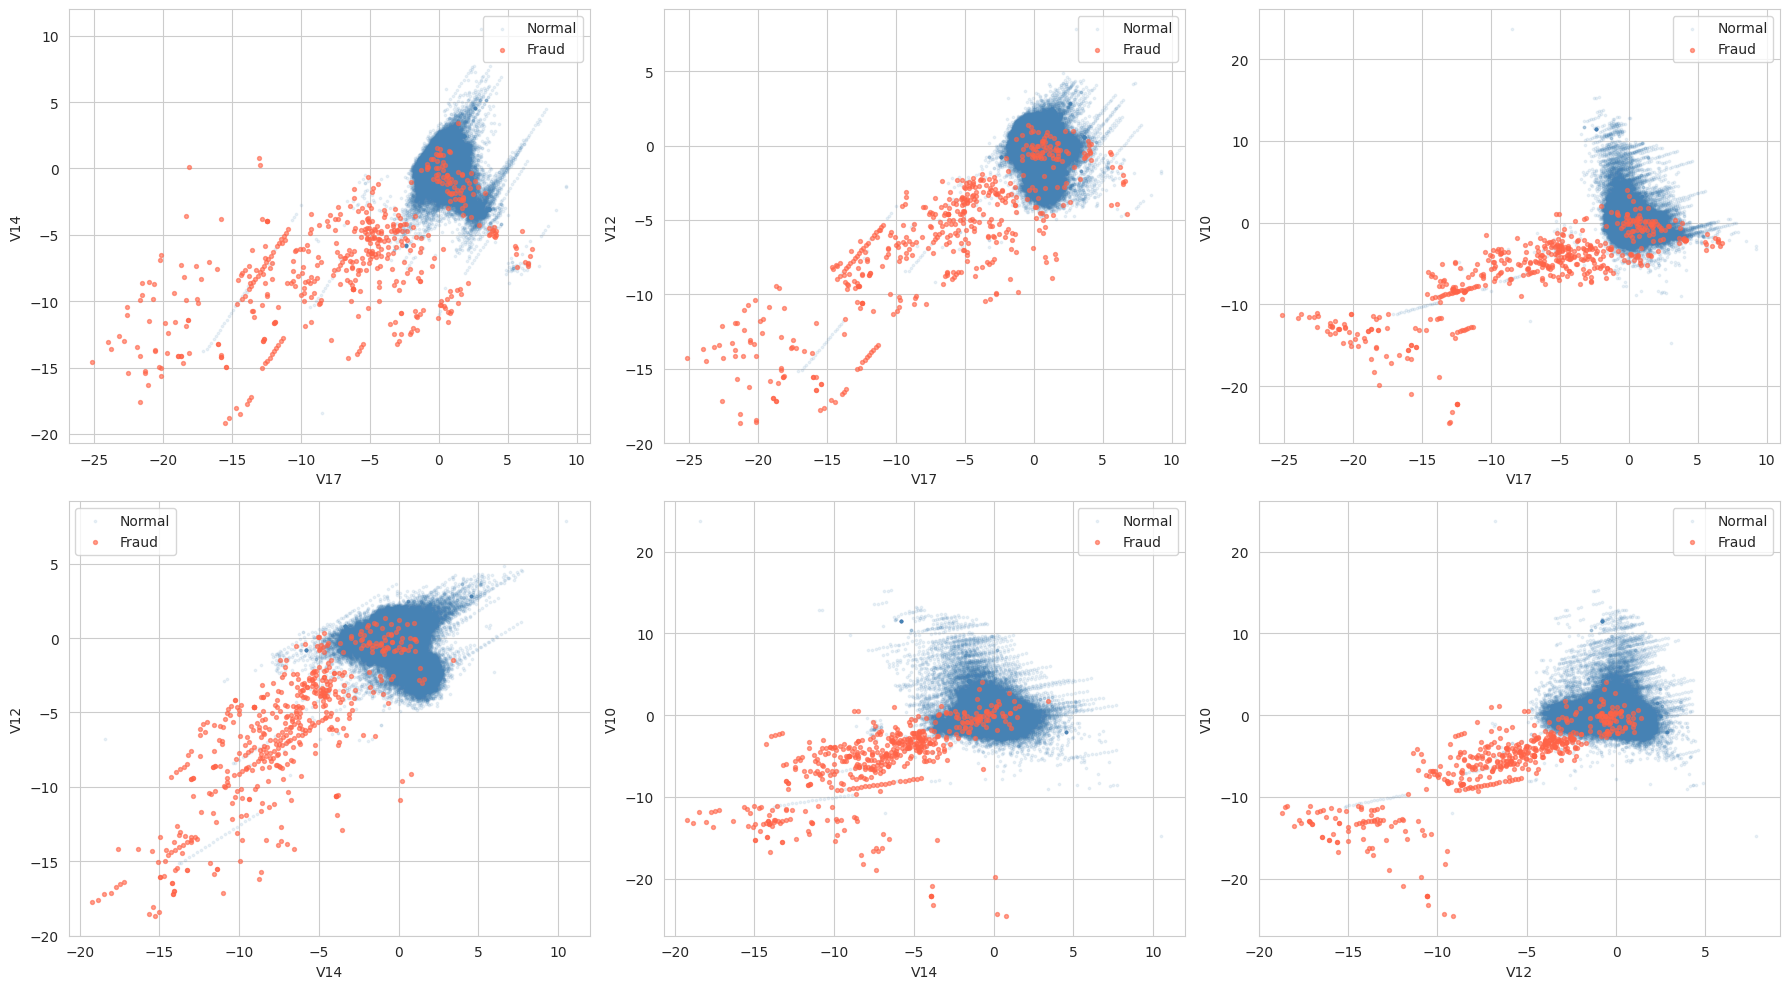

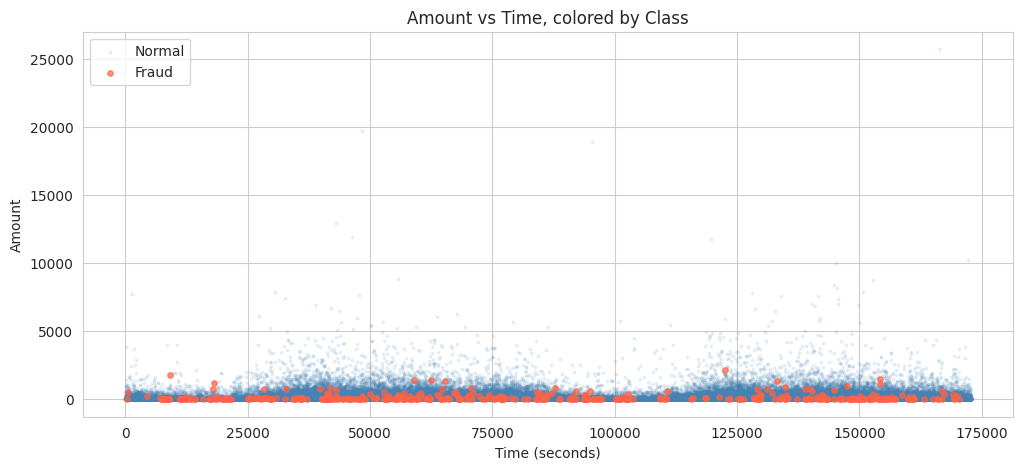

Top 10 correlated V-feature pairs (should be near-zero, confirming PCA orthogonality):
V12  V13    2.321486e-14
V17  V18    4.894901e-15
V9   V14    3.784757e-15
V21  V22    3.649908e-15
V25  V26    2.646517e-15
V18  V19    2.499138e-15
V16  V17    2.482413e-15
     V18    2.420915e-15
V14  V28    2.289427e-15
V9   V13    2.251072e-15
dtype: float64


In [17]:
# STEP 4: MULTIVARIATE ANALYSIS

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

v_features = [f'V{i}' for i in range(1, 29)]
top_features = corr_with_class.abs().sort_values(ascending=False).head(8).index.tolist()  # from Step 3

# --- 4.1 Pairplot of top correlated features, colored by Class ---
# (subsample normal class for speed/readability — pairplot on 284k rows is unusable)
fraud = df[df['Class'] == 1]
normal_sample = df[df['Class'] == 0].sample(n=2000, random_state=42)
sample_df = pd.concat([fraud, normal_sample])

sns.pairplot(sample_df[top_features[:5] + ['Class']], hue='Class',
             plot_kws={'alpha': 0.5, 's': 15}, diag_kind='kde')
plt.suptitle('Pairplot of Top 5 Features by Class', y=1.02)
plt.show()

# --- 4.2 2D PCA projection of all V-features (sanity check on separability) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[v_features])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(pca_result[df['Class']==0, 0], pca_result[df['Class']==0, 1],
            alpha=0.2, s=5, label='Normal', c='steelblue')
plt.scatter(pca_result[df['Class']==1, 0], pca_result[df['Class']==1, 1],
            alpha=0.8, s=15, label='Fraud', c='tomato')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend()
plt.title('2D PCA Projection (colored by Class)')
plt.show()

print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)

# --- 4.3 Scatter matrix: pairwise combos of top 4 features, fraud highlighted ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
pairs = [(top_features[i], top_features[j])
         for i in range(4) for j in range(i+1, 4)]
axes = axes.flatten()
for i, (f1, f2) in enumerate(pairs):
    axes[i].scatter(df.loc[df['Class']==0, f1], df.loc[df['Class']==0, f2],
                     alpha=0.1, s=3, c='steelblue', label='Normal')
    axes[i].scatter(df.loc[df['Class']==1, f1], df.loc[df['Class']==1, f2],
                     alpha=0.6, s=8, c='tomato', label='Fraud')
    axes[i].set_xlabel(f1); axes[i].set_ylabel(f2)
    axes[i].legend()
plt.tight_layout()
plt.show()

# --- 4.4 Amount vs Time, colored by Class ---
plt.figure(figsize=(12, 5))
plt.scatter(df.loc[df['Class']==0, 'Time'], df.loc[df['Class']==0, 'Amount'],
            alpha=0.1, s=3, c='steelblue', label='Normal')
plt.scatter(df.loc[df['Class']==1, 'Time'], df.loc[df['Class']==1, 'Amount'],
            alpha=0.7, s=15, c='tomato', label='Fraud')
plt.xlabel('Time (seconds)'); plt.ylabel('Amount')
plt.legend()
plt.title('Amount vs Time, colored by Class')
plt.show()

# --- 4.5 Multicollinearity check among V-features (should be ~0 since PCA-derived) ---
vif_corr = df[v_features].corr().abs()
high_corr_pairs = vif_corr.where(np.triu(np.ones(vif_corr.shape), k=1).astype(bool)) \
                            .stack().sort_values(ascending=False)
print("Top 10 correlated V-feature pairs (should be near-zero, confirming PCA orthogonality):")
print(high_corr_pairs.head(10))